In [2]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


mean:  0.302
variance:  0.21079599999999993


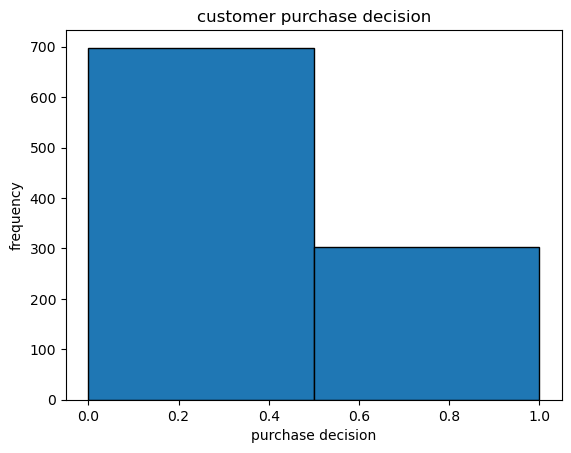

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

p = 0.3
data = bernoulli.rvs(p, size = 1000)

print("mean: ", np.mean(data))
print("variance: ", np.var(data))

plt.hist(data, bins = 2, edgecolor ='black')
plt.xlabel("purchase decision")
plt.ylabel("frequency")
plt.title("customer purchase decision")
plt.show()

most likely:  15


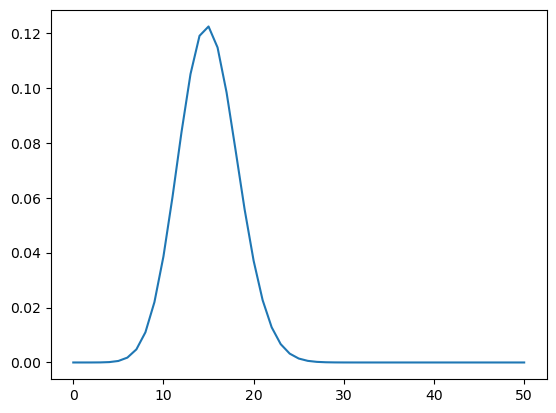

In [4]:
from scipy.stats import binom
import matplotlib.pyplot as plt

n, p = 50, 0.3
x = range(n+1)
pmf = binom.pmf(x, n, p)

print("most likely: ", np.argmax(pmf))

plt.plot(x, pmf)
plt.show()

p(X=8):  0.11259903214902009
p(X>15):  0.04874040330397866


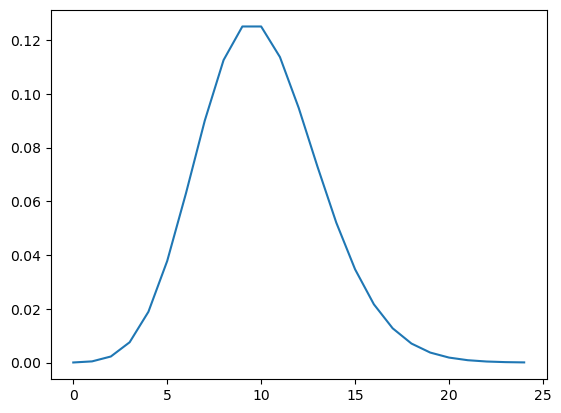

In [5]:
from scipy.stats import poisson
import matplotlib.pyplot as plt

lam = 10

print("p(X=8): ", poisson.pmf(8, lam))
print("p(X>15): ", 1-poisson.cdf(15, lam))

x = range(25)
plt.plot(x, poisson.pmf(x,lam))
plt.show()

In [6]:
import numpy as np

print(df.info())
print(df.describe())

num = df.select_dtypes(include=np.number)

print("mean:\n", num.mean())
print("variance:\n", num.var())
print("std dev:\n", num.std())
print("range:\n", num.max() - num.min())

print("highest varience:\n", num.var().idxmax())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.1+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

num = df.select_dtypes(include = np.number)

mm = MinMaxScaler()
df_mm = pd.DataFrame(mm.fit_transform(num), columns = num.columns) 
print(df_mm.head())

ss = StandardScaler()
df_ss = pd.DataFrame(ss.fit_transform(num), columns = num. columns)
print(df_ss.head())

print("before:\n", num.mean(), "\n", num.var())
print("after:\n", df_ss.mean(), "\n", df_ss.var())

   CustomerID       Age  Annual Income (k$)  Spending Score (1-100)
0    0.000000  0.019231            0.000000                0.387755
1    0.005025  0.057692            0.000000                0.816327
2    0.010050  0.038462            0.008197                0.051020
3    0.015075  0.096154            0.008197                0.775510
4    0.020101  0.250000            0.016393                0.397959
   CustomerID       Age  Annual Income (k$)  Spending Score (1-100)
0   -1.723412 -1.424569           -1.738999               -0.434801
1   -1.706091 -1.281035           -1.738999                1.195704
2   -1.688771 -1.352802           -1.700830               -1.715913
3   -1.671450 -1.137502           -1.700830                1.040418
4   -1.654129 -0.563369           -1.662660               -0.395980
before:
 CustomerID                100.50
Age                        38.85
Annual Income (k$)         60.56
Spending Score (1-100)     50.20
dtype: float64 
 CustomerID                

In [8]:
from scipy.spatial.distance import euclidean

a, b = num.iloc[0], num.iloc[1]
d1 = euclidean(a, b)

a_s, b_s = df_ss.iloc[0], df_ss.iloc[1]
d2 = euclidean(a_s, b_s)

print("before:\n", d1)
print("after:\n", d2)

before:
 42.05948168962618
after:
 1.6369026197949093
